# Loading and Visualizing Data: DCLA Cultural Organizations

### Reading New York City's cultural infrastructure as a curatorial network

This notebook examines the spatial distribution of organizations listed in the **New York City Department of Cultural Affairs (DCLA) Cultural Organizations** dataset. It treats cultural institutions not only as individual venues, but also as nodes in an urban network: their borough locations and disciplinary identities reveal how cultural visibility, access, and specialization are distributed across the city.

**Data source:** [NYC Open Data — DCLA Cultural Organizations](https://data.cityofnewyork.us/d/u35m-9t32)  
**Boundary source:** [NYC Open Data — Borough Boundaries](https://data.cityofnewyork.us/d/gthc-hcne)

The workflow follows the structure of the course tutorials [Comparing Census Variables](https://mapping-systems.org/lessons/tutorials/comparing-census-variables/) and [Flood Vulnerability Proportional Split](https://mapping-systems.org/lessons/tutorials/flood-vulnerability-proportional-split/): import the libraries, prepare the data, inspect key attributes, and layer GeoDataFrames on a shared Matplotlib axis.


## Imports

`pandas` handles the CSV table, `geopandas` handles the GeoJSON and point geometry, and `matplotlib` creates the charts.


In [11]:
# Import the three libraries used in this analysis.
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Set a default figure size, similar to the course tutorials.
plt.rcParams["figure.figsize"] = (10, 10)

## Preparing the data

First, load the cultural organizations CSV and the NYC Borough Boundaries GeoJSON. Local files are used when they are available; the official NYC Open Data links provide a fallback.


In [12]:
# Try to load the cultural organizations CSV from the notebook folder.
try:
    df = pd.read_csv("DCLA_Cultural_Organizations.csv")
except FileNotFoundError:
    data_url = "https://data.cityofnewyork.us/resource/u35m-9t32.csv?$limit=50000"
    df = pd.read_csv(data_url)

# Try to load the borough boundary GeoJSON from the notebook folder.
try:
    boroughs_gdf = gpd.read_file("NYC_Borough_Boundaries.geojson")
except FileNotFoundError:
    boundary_url = "https://data.cityofnewyork.us/resource/gthc-hcne.geojson?$limit=10"
    boroughs_gdf = gpd.read_file(boundary_url)

# Make the CSV column names consistent and easy to type.
df.columns = df.columns.str.strip().str.lower()

# Show the first five rows and the size of the original table.
print("Original table shape:", df.shape)
df.head()

Original table shape: (2535, 16)


,organization_name,address,city,state,postcode,main_phone,discipline,council_district,community_board,borough,latitude,longitude,census_tract,bin,bbl,nta
0,122 Community Center Inc.,150 First Avenue,New York,NY,10009,(917) 864-5050,NaN,Manhattan Council District #2,NaN,Manhattan,40.728261,-73.984785,34.0,1005894.0,1.004370e+09,MN0303
1,"13 Playwrights, Inc.",c/o Gary Winter,Brooklyn,NY,11205,(917) 886-6545,Theater,Brooklyn Council District #39,Brooklyn Community Board #6,Manhattan,NaN,NaN,NaN,NaN,NaN,NaN
2,"1687, Inc.",29 Charles Street #6F,New York,NY,10014,(212) 252-3499,"Multi-Discipline, Performing",Manhattan Council District #3,Manhattan Community Board #2,Manhattan,40.735031,-74.002288,73.0,1010876.0,1.006120e+09,MN0203
3,18 Mai Committee,"832 Franklin Avenue, PMB337",Brooklyn,NY,11225,(718) 270-6935,"Multi-Discipline, Performing",Brooklyn Council District #33,Brooklyn Community Board #6,Brooklyn,40.669459,-73.958419,213.0,3029691.0,3.011870e+09,BK0901
4,20/20 Vision for Schools,428 East 10th Street,New York,NY,10009,(347) 921-4426,Visual Arts,Brooklyn Council District #43,Manhattan Community Board #3,Manhattan,40.725251,-73.976059,28.0,1077210.0,1.003790e+09,MN0303


## Cleaning and creating point geometry

Latitude and longitude are converted to numbers, and rows without valid coordinates are removed. `gpd.points_from_xy()` then converts the cleaned table into a point GeoDataFrame with the WGS 84 coordinate system (`EPSG:4326`).


In [13]:
# Convert the coordinate columns to numbers.
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

# Remove organizations without coordinates.
df_clean = df.dropna(subset=["latitude", "longitude"]).copy()

# Keep only coordinates inside a broad New York City area.
df_clean = df_clean[
    df_clean["latitude"].between(40.45, 40.95)
    & df_clean["longitude"].between(-74.30, -73.65)
].copy()

# Give missing discipline values a readable name.
df_clean["discipline"] = df_clean["discipline"].fillna("Unspecified")

# Convert longitude and latitude into point geometry.
organizations_gdf = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean["longitude"], df_clean["latitude"]),
    crs="EPSG:4326",
)

# Make sure the point layer and borough layer use the same coordinate system.
boroughs_gdf = boroughs_gdf.to_crs(organizations_gdf.crs)

# Check how many records remain after cleaning.
print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(organizations_gdf))
print("Rows removed:", len(df) - len(organizations_gdf))
organizations_gdf[["discipline", "borough", "latitude", "longitude", "geometry"]].head()

Rows before cleaning: 2535
Rows after cleaning: 2268
Rows removed: 267


,discipline,borough,latitude,longitude,geometry
0,Unspecified,Manhattan,40.728261,-73.984785,POINT (-73.98478 40.72826)
2,"Multi-Discipline, Performing",Manhattan,40.735031,-74.002288,POINT (-74.00229 40.73503)
3,"Multi-Discipline, Performing",Brooklyn,40.669459,-73.958419,POINT (-73.95842 40.66946)
4,Visual Arts,Manhattan,40.725251,-73.976059,POINT (-73.97606 40.72525)
5,"Multi-Discipl, Perf & Non-Perf",Brooklyn,40.683468,-73.964853,POINT (-73.96485 40.68347)


## Data Analysis & Reflections

### Thought Process

I chose to map the **Borough** and **Discipline** attributes to uncover structural patterns in New York City's cultural infrastructure. Borough provides a recognizable administrative geography for comparing institutional concentration, while Discipline describes the cultural or curatorial focus through which each organization enters the city's public cultural system. Latitude and longitude transform these attributes into spatial nodes, allowing disciplinary categories to be read as overlapping urban networks rather than as an abstract list.

By contrasting administrative divisions with institutional focus, I aim to visualize how geography shapes the city's **cultural landscape**—a critical foundation for my interest in urban curation and design. Exploring whether visual arts, theater, history, or multi-disciplinary organizations cluster in particular areas can reveal potential cultural corridors and raise questions about transit, real estate, funding ecosystems, and the planning of cultural infrastructure.

## Exploring a non-spatial attribute

Before mapping, use `value_counts()` to inspect how the organizations are distributed across the five boroughs. This mirrors the tutorials' practice of examining a variable before interpreting its spatial pattern.


,count,percentage
borough,,
Manhattan,1339,59.0
Brooklyn,533,23.5
Queens,230,10.1
Bronx,107,4.7
Staten Island,59,2.6


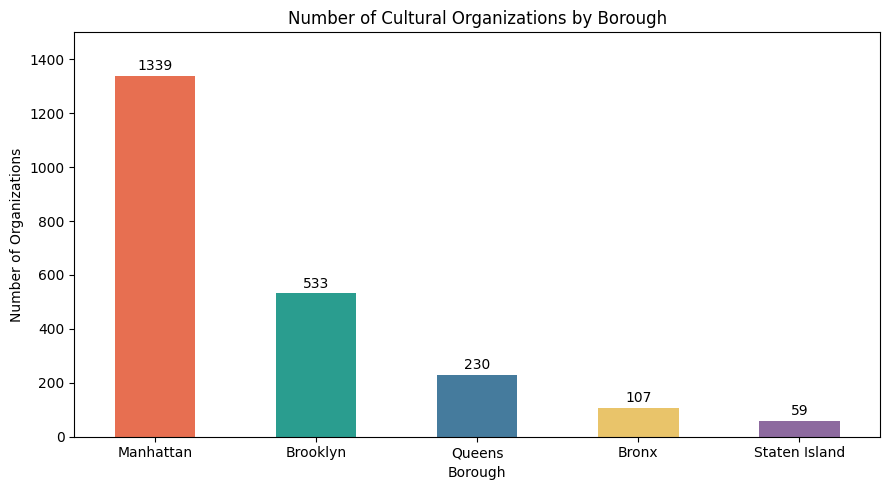

In [14]:
# Count the organizations in each borough.
borough_order = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
borough_counts = organizations_gdf["borough"].value_counts().reindex(borough_order)

# Display the counts and percentages as a small table.
borough_summary = pd.DataFrame({"count": borough_counts})
borough_summary["percentage"] = (
    borough_summary["count"] / borough_summary["count"].sum() * 100
)
display(borough_summary.round(1))

# Plot the borough counts as a bar chart.
borough_colors = ["#E76F51", "#2A9D8F", "#457B9D", "#E9C46A", "#8D6A9F"]
ax = borough_counts.plot(kind="bar", color=borough_colors, figsize=(9, 5))

# Add the exact count above each bar.
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        str(int(bar.get_height())),
        ha="center",
    )

ax.set_title("Number of Cultural Organizations by Borough")
ax.set_xlabel("Borough")
ax.set_ylabel("Number of Organizations")
ax.set_ylim(0, borough_counts.max() * 1.12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Mapping disciplinary networks

The map uses the same layered structure seen in the course tutorials: first plot the borough polygons as a neutral base layer, then plot the cultural organizations on the same `ax`. The six most common disciplines receive distinct colors, while smaller categories are grouped as **Other disciplines**.


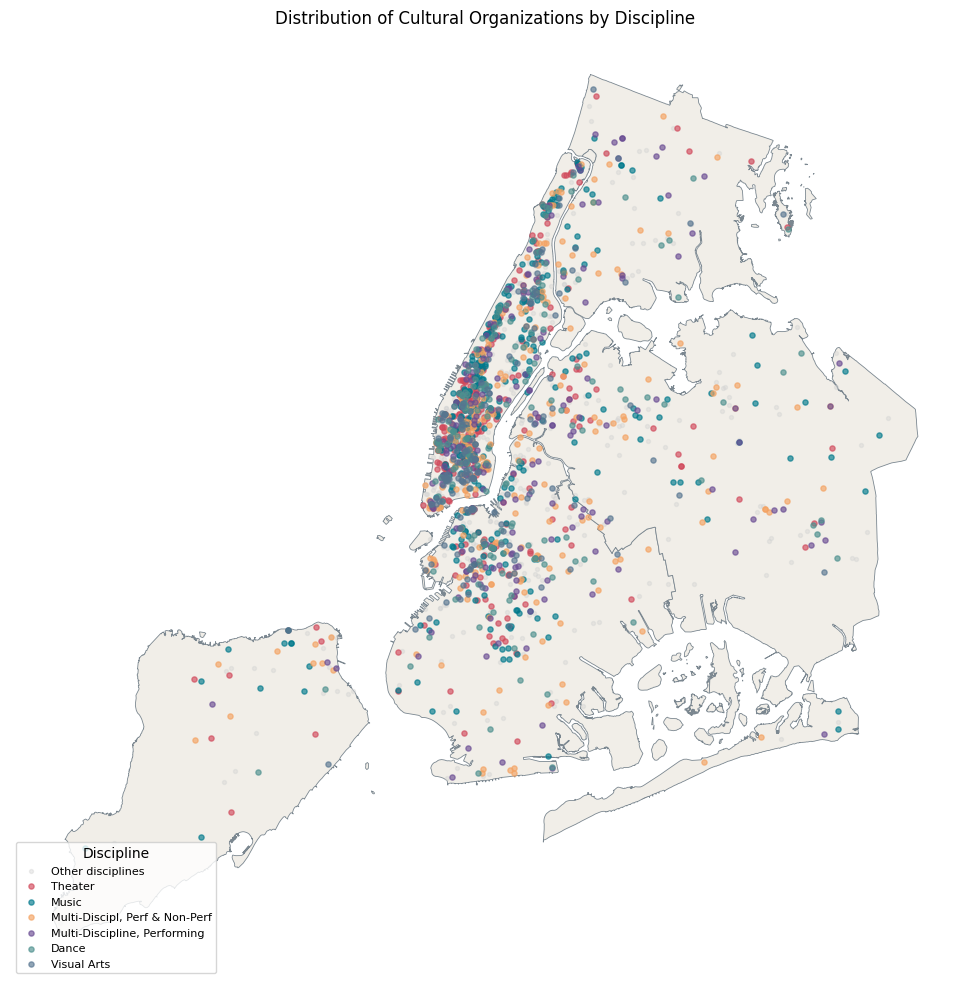

In [15]:
# Find the six most common disciplines.
top_disciplines = organizations_gdf["discipline"].value_counts().head(6).index

# Group all smaller categories as "Other disciplines".
organizations_gdf["discipline_group"] = organizations_gdf["discipline"]
organizations_gdf.loc[
    ~organizations_gdf["discipline"].isin(top_disciplines),
    "discipline_group",
] = "Other disciplines"

# Match each major discipline with a color.
discipline_colors = {
    top_disciplines[0]: "#D1495B",
    top_disciplines[1]: "#00798C",
    top_disciplines[2]: "#F4A261",
    top_disciplines[3]: "#6A4C93",
    top_disciplines[4]: "#4D908E",
    top_disciplines[5]: "#577590",
    "Other disciplines": "lightgray",
}

# Create one shared axis for the boroughs and the cultural organizations.
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the GeoJSON borough polygons first as the background layer.
boroughs_gdf.plot(
    ax=ax,
    color="#F1EEE8",
    edgecolor="#7B8790",
    linewidth=0.6,
)

# Plot the smaller discipline categories first in gray.
organizations_gdf[organizations_gdf["discipline_group"].eq("Other disciplines")].plot(
    ax=ax,
    color="lightgray",
    markersize=8,
    alpha=0.4,
    label="Other disciplines",
)

# Plot each major discipline on top of the borough layer.
for discipline in top_disciplines:
    organizations_gdf[organizations_gdf["discipline_group"].eq(discipline)].plot(
        ax=ax,
        color=discipline_colors[discipline],
        markersize=14,
        alpha=0.65,
        label=discipline,
    )

ax.set_title("Distribution of Cultural Organizations by Discipline")
ax.legend(title="Discipline", loc="lower left", fontsize=8)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Key Findings

The data demonstrates a clear centralization of officially registered cultural resources. **Manhattan acts as the primary hub, containing approximately 59.0% of the mappable organizations, followed by Brooklyn at 23.5%.** The remaining **17.5%** is distributed across Queens, the Bronx, and Staten Island, highlighting a significant imbalance in the city's official cultural footprint.

The point map adds a disciplinary layer to this borough-level imbalance. Dense constellations of institutions can be interpreted as potential **cultural corridors or art clusters**, while the co-location of multiple disciplines suggests a mixed curatorial ecology rather than a single-purpose district. These patterns identify recorded presence and proximity; they should not, by themselves, be interpreted as evidence of cultural quality or equitable access.

### Data Limitations

The dataset tracks organizations officially registered with the DCLA and therefore excludes many independent, underground, informal, mobile, or temporary spaces that are essential to local cultural life—including pop-up exhibitions and short-term curatorial projects. It represents organizations as points but does not account for their **physical scale, architectural quality, budget, or actual exhibition capacity**. A small artist-run space and a major museum consequently appear as equally weighted dots, while overlapping points may conceal several organizations at one address.

The data also does not reflect visitor demographics, attendance, participation, or levels of engagement. A high concentration of organizations therefore does not automatically indicate high cultural accessibility or activity. Missing or inaccurate geocodes may introduce additional bias, and a listed address may be an administrative office rather than the place where audiences encounter the organization's work.

For these reasons, this analysis should be treated as a **diagnostic map of documented cultural infrastructure**, not a complete map of culture itself.

## Reproducibility note

The analysis is shown in a linear order: import libraries, load files, clean the coordinates, create a GeoDataFrame, inspect an attribute, and layer the GeoJSON polygons with the point data. This follows the workflow demonstrated in the course tutorials. Because the official datasets can be updated, counts or boundaries may change if the notebook is re-run against the live links later.
